# Phase 3: 배출량 예측 모델
**알고리즘**: XGBoost Multi-output + SHAP 해석

## 방법론 선정 사유 (보고서 Ⅲ장)
- **XGBoost**: 표형 시계열 데이터에서 최고 성능, 비선형 상호작용 자동 포착
- **Multi-output**: SOx, NOx, 먼지 3개 타겟 동시 예측
- **SHAP**: 블랙박스 모델 해석 → 인과 추론 보조
- **시계열 분할**: 미래 데이터 누수 방지 (Train 80% / Val 10% / Test 10%)

## 최적화 변수 설계
삼천포는 순수 유연탄 발전소(LNG=0)이므로 연료 믹스 대신 **이용률(발전량)**을 최적화 변수로 사용:
- 대기정체 조건에서 이용률 감발 → 배출량 감축
- 감발분은 LNG 발전소(분당화력)로 대체하는 시나리오

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import joblib
import shap
from pathlib import Path

from features import build_features, get_X_y, train_test_split_temporal, TARGET_COLS
from model import train_model, evaluate_model, explain_shap

matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

PROCESSED_DIR = Path('../data/processed')
REPORT_DIR = Path('../reports')
REPORT_DIR.mkdir(exist_ok=True)

## 1. 데이터 로딩 및 특성 생성

In [2]:
master = pd.read_csv(PROCESSED_DIR / 'master_dataset.csv', parse_dates=['date'])
print(f'마스터 데이터: {master.shape}')

feature_df = build_features(master)
feature_df = feature_df.dropna(subset=[t for t in TARGET_COLS if t in feature_df.columns])
# gen_mwh_combined 결측 제거 (최적화 핵심 변수)
if 'gen_mwh_combined' in feature_df.columns:
    feature_df = feature_df.dropna(subset=['gen_mwh_combined'])

print(f'특성 데이터: {feature_df.shape}')
print(f'기간: {feature_df["date"].min().date()} ~ {feature_df["date"].max().date()}')
print(f'\n특성 컬럼: {[c for c in feature_df.columns if c not in ["date"] + TARGET_COLS]}')
feature_df.head()

마스터 데이터: (2123, 36)
특성 데이터: (2114, 34)
기간: 2020-07-16 ~ 2026-04-30

특성 컬럼: ['temp_mean', 'humidity_mean', 'wind_speed_mean', 'wind_speed_max', 'wind_sin', 'wind_cos', 'precipitation', 'pressure_mean', 'solar_radiation', 'stagnation_idx', 'gen_mwh_combined', 'utilization', 'heat_efficiency', '유연탄', 'solar_mwh', 'wind_mwh', 'renewable_ratio', 'month', 'dayofweek', 'season_spring', 'season_summer', 'season_autumn', 'seasonal_mgmt', 'SOx_lag1', 'NOx_lag1', '먼지_lag1', 'SOx_lag7', 'NOx_lag7', '먼지_lag7', 'sox_factor_ma30']


,date,temp_mean,humidity_mean,wind_speed_mean,wind_speed_max,wind_sin,wind_cos,precipitation,pressure_mean,solar_radiation,...,SOx_lag1,NOx_lag1,먼지_lag1,SOx_lag7,NOx_lag7,먼지_lag7,sox_factor_ma30,SOx,NOx,먼지
0,2020-07-16,19.58,89.77,1.35,13.708391,0.929262,0.369422,0.00,1003.76570,24.11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,498925.845294,1.555739e+06,111556.964180
1,2020-07-17,19.55,91.99,2.05,10.895577,0.838671,0.544639,0.00,1005.57690,27.14,...,498925.845294,1.555739e+06,111556.964180,NaN,NaN,NaN,NaN,553145.514900,1.533093e+06,122518.129245
2,2020-07-18,21.63,86.08,1.96,9.021574,0.883030,-0.469317,0.00,1006.29364,13.53,...,553145.514900,1.533093e+06,122518.129245,NaN,NaN,NaN,NaN,526034.253205,1.539783e+06,121284.318937
3,2020-07-19,24.00,99.00,9.08,21.674870,-0.889974,-0.456011,7.75,1004.30230,5.46,...,526034.253205,1.539783e+06,121284.318937,NaN,NaN,NaN,NaN,504067.152773,1.541445e+06,123539.761068
4,2020-07-20,22.61,93.93,1.11,19.652176,0.936916,-0.349553,0.50,1004.22120,8.87,...,504067.152773,1.541445e+06,123539.761068,NaN,NaN,NaN,NaN,559773.602366,1.575632e+06,139324.442524


## 2. 시계열 분할 (Train / Val / Test)

In [3]:
train_df, val_df, test_df = train_test_split_temporal(feature_df, train_ratio=0.8, val_ratio=0.1)

X_train, y_train = get_X_y(train_df)
X_val,   y_val   = get_X_y(val_df)
X_test,  y_test  = get_X_y(test_df)

print(f'\n특성 수: {X_train.shape[1]}')
print(f'타겟 변수: {y_train.columns.tolist()}')
print(f'\n특성 목록:')
for c in X_train.columns:
    print(f'  {c}: mean={X_train[c].mean():.2f}, std={X_train[c].std():.2f}')

Train: 2020-07-16 ~ 2025-03-03 (1691일)
Val  : 2025-03-04 ~ 2025-09-30 (211일)
Test : 2025-10-01 ~ 2026-04-30 (212일)

특성 수: 30
타겟 변수: ['SOx', 'NOx', '먼지']

특성 목록:
  temp_mean: mean=13.85, std=8.59
  humidity_mean: mean=74.03, std=17.36
  wind_speed_mean: mean=4.72, std=4.18
  wind_speed_max: mean=16.48, std=5.57
  wind_sin: mean=0.43, std=0.69
  wind_cos: mean=0.11, std=0.58
  precipitation: mean=2.22, std=8.51
  pressure_mean: mean=1013.11, std=7.67
  solar_radiation: mean=14.67, std=6.50
  stagnation_idx: mean=28.71, std=22.87
  gen_mwh_combined: mean=28792.56, std=9842.54
  utilization: mean=52.58, std=14.52
  heat_efficiency: mean=30.30, std=7.08
  유연탄: mean=12274.68, std=3097.61
  solar_mwh: mean=34.70, std=30.61
  wind_mwh: mean=0.31, std=1.00
  renewable_ratio: mean=0.00, std=0.00
  month: mean=6.66, std=3.53
  dayofweek: mean=3.00, std=2.00
  season_spring: mean=0.22, std=0.41
  season_summer: mean=0.25, std=0.43
  season_autumn: mean=0.27, std=0.44
  seasonal_mgmt: mean=0.34, st

## 3. 모델 학습

In [4]:
print('=== XGBoost Multi-output 모델 학습 ===')
model = train_model(X_train, y_train, X_val, y_val)
print('\n학습 완료')

=== XGBoost Multi-output 모델 학습 ===
  [1/3] SOx 모델 학습 중...
    Best iteration: 85
  [2/3] NOx 모델 학습 중...
    Best iteration: 48
  [3/3] 먼지 모델 학습 중...
    Best iteration: 20

학습 완료


## 4. 성능 평가 (RMSE, MAE, R²)

In [5]:
print('=== Validation 성능 ===')
val_metrics = evaluate_model(model, X_val, y_val, 'Validation')

print('\n=== Test 성능 ===')
test_metrics = evaluate_model(model, X_test, y_test, 'Test')

test_metrics.to_csv(REPORT_DIR / 'model_performance.csv', index=False, encoding='utf-8-sig')
print('\n성능 결과 저장: reports/model_performance.csv')

=== Validation 성능 ===
  Validation | SOx: RMSE=72015.97, MAE=54584.49, R²=0.8740
  Validation | NOx: RMSE=127775.04, MAE=94927.49, R²=0.7709
  Validation | 먼지: RMSE=386530.86, MAE=204995.37, R²=0.1082

=== Test 성능 ===
  Test | SOx: RMSE=105649.33, MAE=72790.87, R²=0.7337
  Test | NOx: RMSE=219620.95, MAE=142012.66, R²=0.4567
  Test | 먼지: RMSE=2307490.39, MAE=578711.23, R²=-0.0340

성능 결과 저장: reports/model_performance.csv


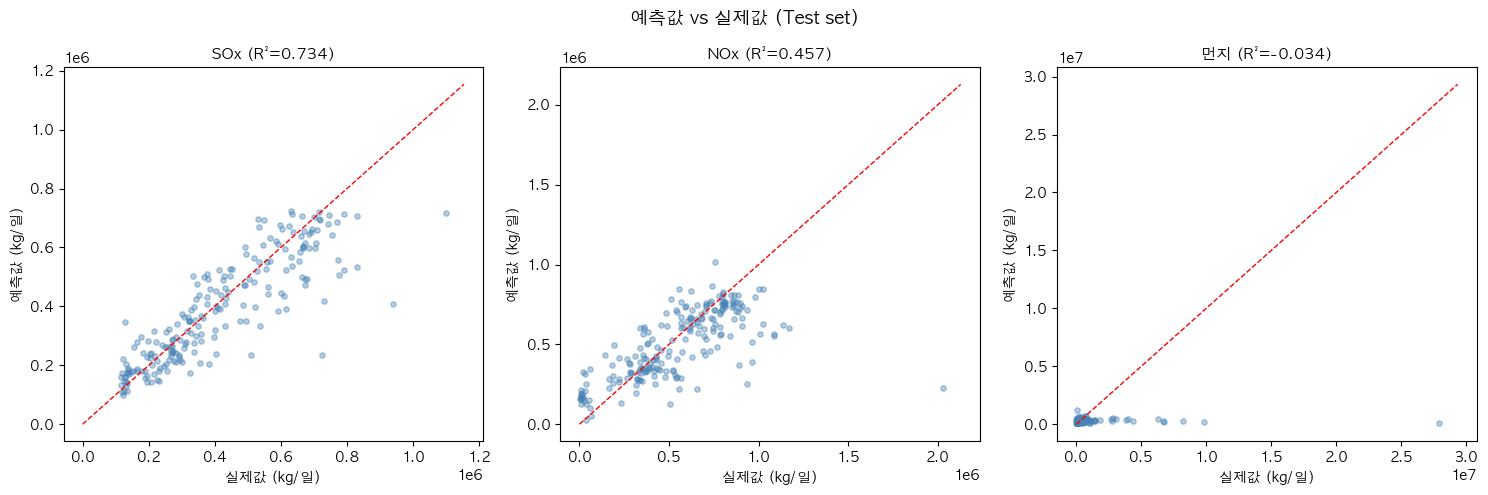

[저장] model_01_pred_vs_actual.png


In [6]:
# 예측 vs 실제 시각화
y_pred_test = pd.DataFrame(
    model.predict(X_test),
    columns=y_test.columns,
    index=y_test.index,
)

fig, axes = plt.subplots(1, len(y_test.columns), figsize=(15, 5))
if len(y_test.columns) == 1:
    axes = [axes]

for ax, col in zip(axes, y_test.columns):
    ax.scatter(y_test[col], y_pred_test[col], alpha=0.4, s=15, color='steelblue')
    lim = max(y_test[col].max(), y_pred_test[col].max()) * 1.05
    ax.plot([0, lim], [0, lim], 'r--', lw=1)
    r2 = test_metrics[test_metrics['target'] == col]['R2'].values
    r2_str = f'{r2[0]:.3f}' if len(r2) > 0 else 'N/A'
    ax.set_title(f'{col} (R²={r2_str})', fontsize=11)
    ax.set_xlabel('실제값 (kg/일)')
    ax.set_ylabel('예측값 (kg/일)')

plt.suptitle('예측값 vs 실제값 (Test set)', fontsize=13)
plt.tight_layout()
plt.savefig(REPORT_DIR / 'model_01_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print('[저장] model_01_pred_vs_actual.png')

## 5. SHAP 변수 중요도 해석
인과적 해석: '어떤 변수가 배출량을 얼마나 증가/감소시키는가'

In [7]:
shap_values = explain_shap(
    model,
    X_test,
    feature_names=X_test.columns.tolist(),
    target_names=y_test.columns.tolist(),
    save_dir=REPORT_DIR,
)

  SHAP 계산: SOx
    저장: shap_SOx.png
  SHAP 계산: NOx
    저장: shap_NOx.png
  SHAP 계산: 먼지
    저장: shap_먼지.png

상위 10개 중요 변수:
                           SOx            NOx            먼지          total
gen_mwh_combined  68704.960938   99907.890625  70007.593750  238620.437500
NOx_lag1          14973.717773  101808.132812   4020.807129  120802.656250
SOx_lag1          90912.398438   17724.441406   9624.052734  118260.898438
NOx_lag7           5050.528320   36277.394531   8710.987305   50038.910156
먼지_lag1            4825.337891   12030.210938  31304.117188   48159.664062
solar_mwh          1100.619141   15821.676758  18786.388672   35708.687500
먼지_lag7            2574.947266    2066.540771  28099.398438   32740.886719
heat_efficiency    2329.268799   14874.395508   9343.854492   26547.519531
dayofweek         10732.113281   12520.237305   3262.827148   26515.179688
solar_radiation    3706.910889    4470.178223  14787.369141   22964.457031


## 6. 핵심 가설 검증: 이용률 × 대기정체 → NOx 영향

**가설**: "대기정체 조건(stagnation_idx 상위)에서 이용률 10% 감축 시 NOx Y% 저감"

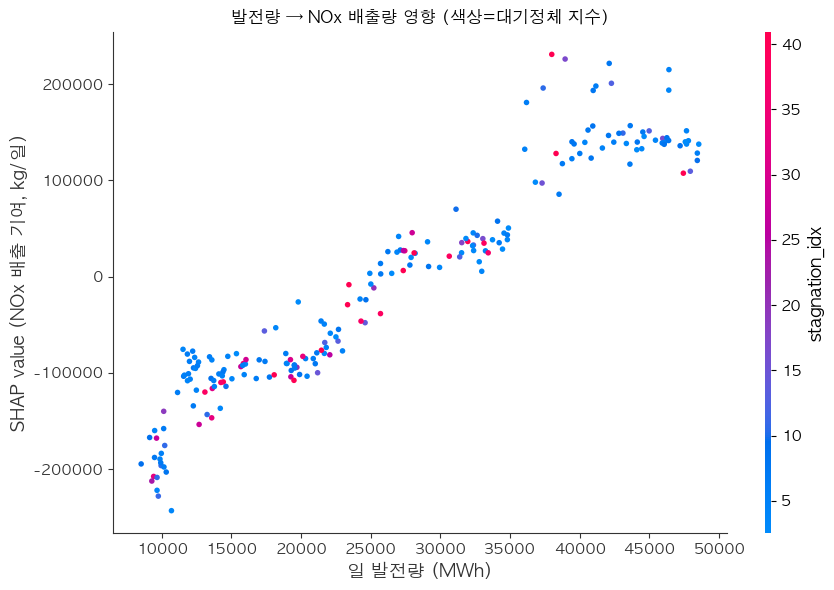

[저장] model_02_shap_gen_nox.png


In [8]:
# SHAP dependency plot: gen_mwh_combined → NOx (색상=stagnation_idx)
key_feature = 'gen_mwh_combined' if 'gen_mwh_combined' in X_test.columns else 'utilization'

if 'NOx' in y_test.columns and key_feature in X_test.columns:
    nox_idx = y_test.columns.tolist().index('NOx')
    explainer = shap.TreeExplainer(model.estimators_[nox_idx])
    sv = explainer.shap_values(X_test)

    interaction = 'stagnation_idx' if 'stagnation_idx' in X_test.columns else None

    fig, ax = plt.subplots(figsize=(9, 6))
    shap.dependence_plot(
        key_feature, sv, X_test,
        interaction_index=interaction,
        show=False, ax=ax,
    )
    ax.set_title(f'발전량 → NOx 배출량 영향 (색상=대기정체 지수)', fontsize=12)
    ax.set_xlabel('일 발전량 (MWh)')
    ax.set_ylabel('SHAP value (NOx 배출 기여, kg/일)')
    plt.tight_layout()
    plt.savefig(REPORT_DIR / 'model_02_shap_gen_nox.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('[저장] model_02_shap_gen_nox.png')

In [9]:
# 이용률 구간별 NOx 감축 효과 정량화 (보고서 Ⅰ장 인과 가설 수치화)
if 'utilization' in X_test.columns:
    high_stag = X_test[X_test['stagnation_idx'] >= X_test['stagnation_idx'].quantile(0.75)]
    low_stag  = X_test[X_test['stagnation_idx'] <= X_test['stagnation_idx'].quantile(0.25)]

    for group_name, group in [('대기정체 심각 (상위25%)', high_stag),
                               ('대기유동 원활 (하위25%)', low_stag)]:
        if group.empty:
            continue
        base_row = group.mean().to_frame().T.reset_index(drop=True)

        results = []
        for util_delta in [-0.20, -0.10, 0, 0.10]:
            row = base_row.copy()
            if 'utilization' in row.columns:
                row['utilization'] = (row['utilization'] + util_delta * 100).clip(15, 95)
            if 'gen_mwh_combined' in row.columns:
                row['gen_mwh_combined'] = row['gen_mwh_combined'] * (1 + util_delta)
            pred = model.predict(row)[0]
            results.append({'이용률_변화': f'{util_delta*100:+.0f}%', 'NOx_kg': pred[1] if len(pred) > 1 else pred[0]})

        df_r = pd.DataFrame(results)
        base_nox = df_r[df_r['이용률_변화']=='  +0%']['NOx_kg'].values
        base_nox = df_r.iloc[2]['NOx_kg']
        df_r['NOx_변화율(%)'] = ((df_r['NOx_kg'] - base_nox) / base_nox * 100).round(1)
        print(f'\n[{group_name}]')
        print(df_r.to_string(index=False))


[대기정체 심각 (상위25%)]
이용률_변화       NOx_kg  NOx_변화율(%)
  -20% 463753.06250       -10.5
  -10% 479050.78125        -7.5
   +0% 517880.21875         0.0
  +10% 514391.03125        -0.7

[대기유동 원활 (하위25%)]
이용률_변화      NOx_kg  NOx_변화율(%)
  -20% 527028.2500       -10.2
  -10% 579846.6875        -1.2
   +0% 587176.0000         0.0
  +10% 607171.8125         3.4


In [10]:
# 모델 저장
joblib.dump(model, REPORT_DIR / 'emission_model.pkl')
print('[OK] 모델 저장: reports/emission_model.pkl')
print(f'\n=== 최종 모델 성능 요약 ===')
print(test_metrics.to_string(index=False))

[OK] 모델 저장: reports/emission_model.pkl

=== 최종 모델 성능 요약 ===
target         RMSE           MAE        R2
   SOx 1.056493e+05  72790.873391  0.733734
   NOx 2.196210e+05 142012.661440  0.456674
    먼지 2.307490e+06 578711.228320 -0.034045
